Install Dependencies

In [ ]:
%%capture
!pip install kaggle transformers sumy rouge-score nltk gradio matplotlib seaborn wordcloud pandas numpy scikit-learn torch sentencepiece

 Kaggle API Setup


In [ ]:
import os
from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle API configured!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API configured!


 Download Dataset

In [ ]:
!kaggle datasets download -d marawanxmamdouh/email-thread-summary-dataset --unzip -p ./data
!ls ./data

Dataset URL: https://www.kaggle.com/datasets/marawanxmamdouh/email-thread-summary-dataset
License(s): other
100% 23.6M/23.6M [00:00<00:00, 85.5MB/s]

CSV  JSON  Pickle


In [ ]:
import pandas as pd
import numpy as np
import glob

# Auto-detect CSV file
csv_files = glob.glob('./data/**/*.csv', recursive=True) + glob.glob('./data/*.csv')
print("Found files:", csv_files)

df = pd.read_csv(csv_files[0])
print(f"\nShape: {df.shape}")
print("\nColumns:", df.columns.tolist())
df.head(3)

Found files: ['./data/CSV/email_thread_details.csv', './data/CSV/email_thread_summaries.csv']

Shape: (21684, 6)

Columns: ['thread_id', 'subject', 'timestamp', 'from', 'to', 'body']


,thread_id,subject,timestamp,from,to,body
0,1,FW: Master Termination Log,2002-01-29 11:23:42,"Gossett, Jeffrey C. JGOSSET","['Giron', 'Darron C. Dgiron', 'Love', 'Phillip...",\n\n -----Original Message-----\nFrom: =09Ther...
1,1,FW: Master Termination Log,2002-01-31 12:50:00,"Theriot, Kim S. KTHERIO","['Murphy', 'Melissa Mmurphy', 'Gossett', 'Jeff...",\n\n -----Original Message-----\nFrom: =09Panu...
2,1,FW: Master Termination Log,2002-02-05 15:03:35,"Theriot, Kim S. KTHERIO","['Murphy', 'Melissa Mmurphy', 'Anderson', 'Dia...",Note to Stephanie Panus....\n\nStephanie...ple...


In [ ]:
import pandas as pd
import glob



# Load the main dataframe
df = pd.read_csv(csv_files[0]) # This is email_thread_details.csv

# Identify the email body column
email_col_name = 'body'
if email_col_name not in df.columns:
    raise ValueError(f"Expected column '{email_col_name}' not found in {csv_files[0]}.")

# Rename the email column to 'email' for consistency
df = df.rename(columns={email_col_name: 'email'})

# Load the summaries dataframe (email_thread_summaries.csv)
df_summaries = pd.read_csv(csv_files[1]) # This is email_thread_summaries.csv

# Identify the summary column
summary_col_name = 'summary'
if summary_col_name not in df_summaries.columns:
    raise ValueError(f"Expected column '{summary_col_name}' not found in {csv_files[1]}.")

# Rename the summary column to 'summary'
df_summaries = df_summaries.rename(columns={summary_col_name: 'summary'})

# Assuming 'thread_id' is the common column to merge both dataframes

if 'thread_id' not in df.columns or 'thread_id' not in df_summaries.columns:
    raise ValueError("Both dataframes must contain a 'thread_id' column for merging.")

# Merge the two dataframes on 'thread_id'

df = pd.merge(df, df_summaries[['thread_id', 'summary']], on='thread_id', how='inner')

# Print the effective mapping found for clarity
print(f"Auto-detected mapping: {{'email': '{email_col_name}', 'summary': '{summary_col_name}'}}")

# Original subsequent filtering and cleaning steps (these remain the same)
df = df[['email', 'summary']].dropna().reset_index(drop=True)
df['email']   = df['email'].astype(str).str.strip()
df['summary'] = df['summary'].astype(str).str.strip()
df = df[df['email'].str.len() > 50]

print(f"Clean dataset size: {len(df)}")
df.head(3)

Auto-detected mapping: {'email': 'body', 'summary': 'summary'}
Clean dataset size: 20881


,email,summary
0,"-----Original Message-----\nFrom: =09Theriot, ...",The email thread discusses the Master Terminat...
1,"-----Original Message-----\nFrom: =09Panus, St...",The email thread discusses the Master Terminat...
2,Note to Stephanie Panus....\n\nStephanie...ple...,The email thread discusses the Master Terminat...


 Exploratory Data Analysis (EDA)

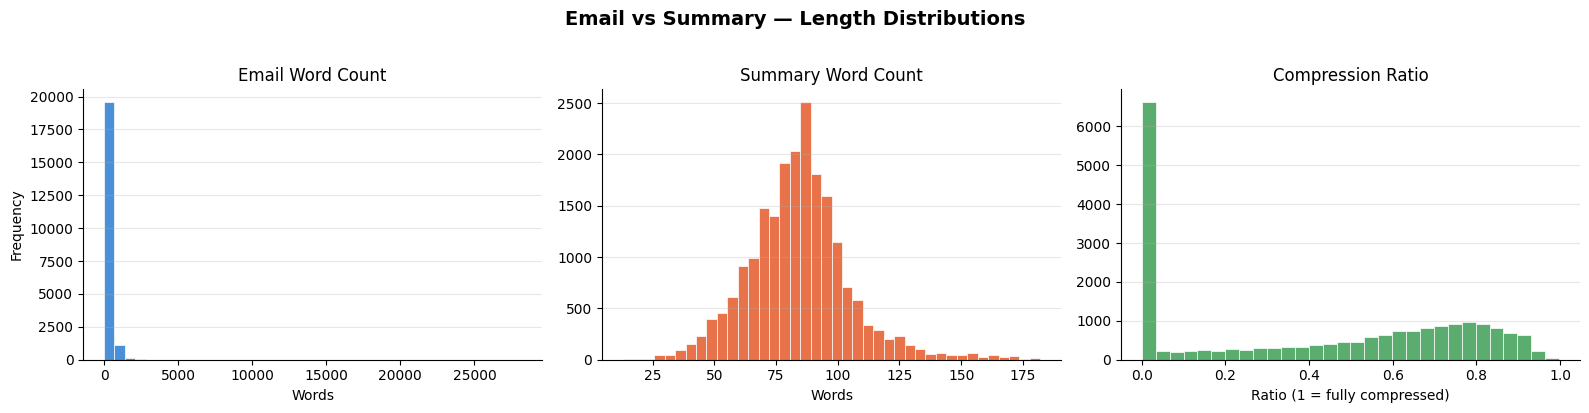

✅ Saved: eda_length_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter
import re

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
STOPS = set(stopwords.words('english'))

os.makedirs('./outputs', exist_ok=True)

# --- Compute lengths ---
df['email_len']   = df['email'].apply(lambda x: len(x.split()))
df['summary_len'] = df['summary'].apply(lambda x: len(x.split()))
df['email_chars'] = df['email'].str.len()
df['compression'] = (1 - df['summary_len'] / df['email_len']).clip(0, 1)

# ============================================================
# FIGURE 1 — Length Distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Email vs Summary — Length Distributions', fontsize=14, fontweight='bold', y=1.02)

axes[0].hist(df['email_len'],   bins=40, color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Email Word Count'); axes[0].set_xlabel('Words'); axes[0].set_ylabel('Frequency')

axes[1].hist(df['summary_len'], bins=40, color='#E8734A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Summary Word Count'); axes[1].set_xlabel('Words')

axes[2].hist(df['compression'], bins=30, color='#5BAD6F', edgecolor='white', linewidth=0.5)
axes[2].set_title('Compression Ratio'); axes[2].set_xlabel('Ratio (1 = fully compressed)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/eda_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_length_distribution.png")

/tmp/ipykernel_1116/4026880158.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=['Email', 'Summary'], patch_artist=True,


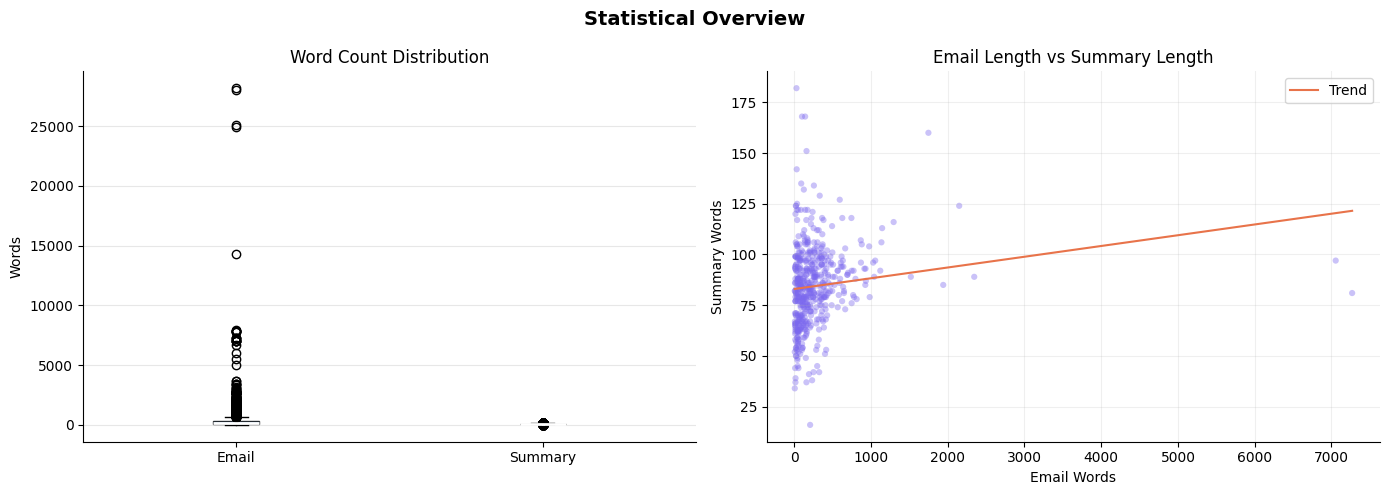

✅ Saved: eda_statistical_overview.png


In [ ]:
# ============================================================
# FIGURE 2 — Box Plots & Correlation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Statistical Overview', fontsize=14, fontweight='bold')

# Box plot
data_box = [df['email_len'].values, df['summary_len'].values]
bp = axes[0].boxplot(data_box, labels=['Email', 'Summary'], patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
colors = ['#4A90D9', '#E8734A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_title('Word Count Distribution'); axes[0].set_ylabel('Words')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Scatter: email len vs summary len
sample = df.sample(min(500, len(df)), random_state=42)
axes[1].scatter(sample['email_len'], sample['summary_len'],
                alpha=0.4, color='#7B68EE', s=20, edgecolors='none')
# Trend line
z = np.polyfit(sample['email_len'], sample['summary_len'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['email_len'].min(), sample['email_len'].max(), 100)
axes[1].plot(x_line, p(x_line), color='#E8734A', linewidth=1.5, label='Trend')
axes[1].set_title('Email Length vs Summary Length')
axes[1].set_xlabel('Email Words'); axes[1].set_ylabel('Summary Words')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('./outputs/eda_statistical_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_statistical_overview.png")

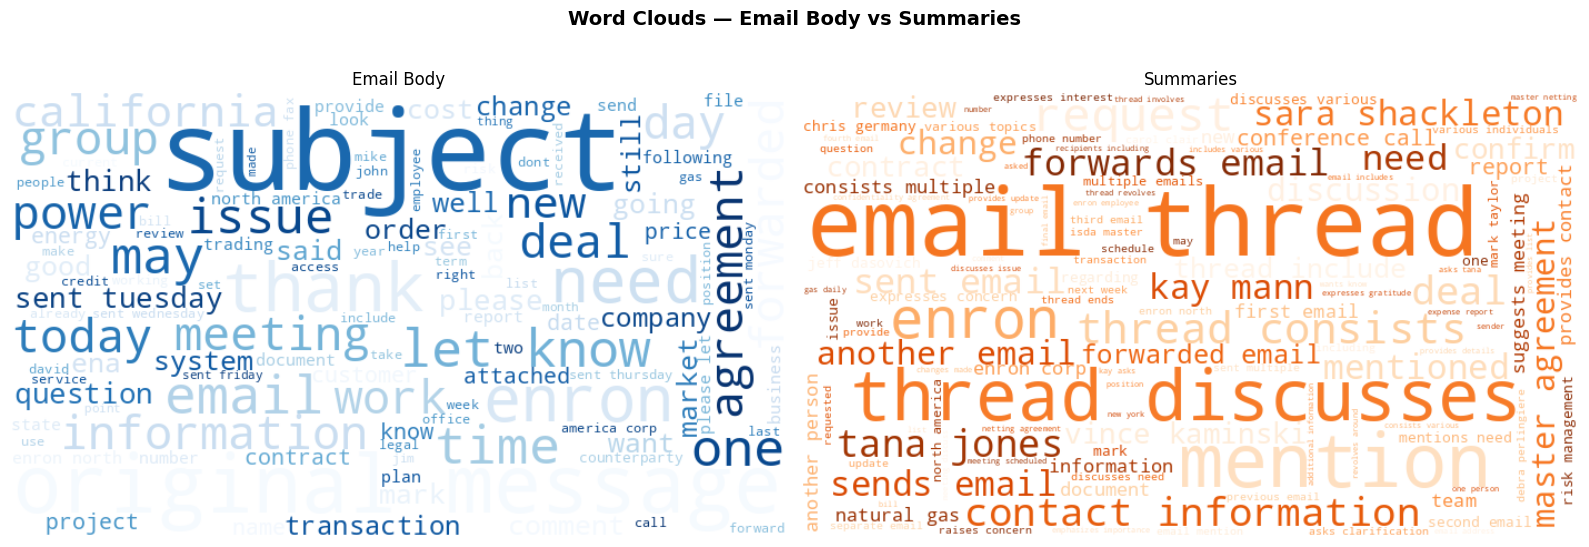

✅ Saved: eda_wordclouds.png


In [ ]:
# ============================================================
# FIGURE 3 — Word Clouds (Email vs Summary)
# ============================================================
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    return ' '.join(w for w in text.split() if w not in STOPS and len(w) > 2)

email_corpus   = ' '.join(df['email'].sample(min(500, len(df))).apply(clean_text))
summary_corpus = ' '.join(df['summary'].apply(clean_text))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds — Email Body vs Summaries', fontsize=14, fontweight='bold')

wc_email = WordCloud(width=700, height=400, background_color='white',
                     colormap='Blues', max_words=120, prefer_horizontal=0.9)
wc_email.generate(email_corpus)
axes[0].imshow(wc_email, interpolation='bilinear')
axes[0].set_title('Email Body', fontsize=12); axes[0].axis('off')

wc_sum = WordCloud(width=700, height=400, background_color='white',
                   colormap='Oranges', max_words=120, prefer_horizontal=0.9)
wc_sum.generate(summary_corpus)
axes[1].imshow(wc_sum, interpolation='bilinear')
axes[1].set_title('Summaries', fontsize=12); axes[1].axis('off')

plt.tight_layout()
plt.savefig('./outputs/eda_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_wordclouds.png")

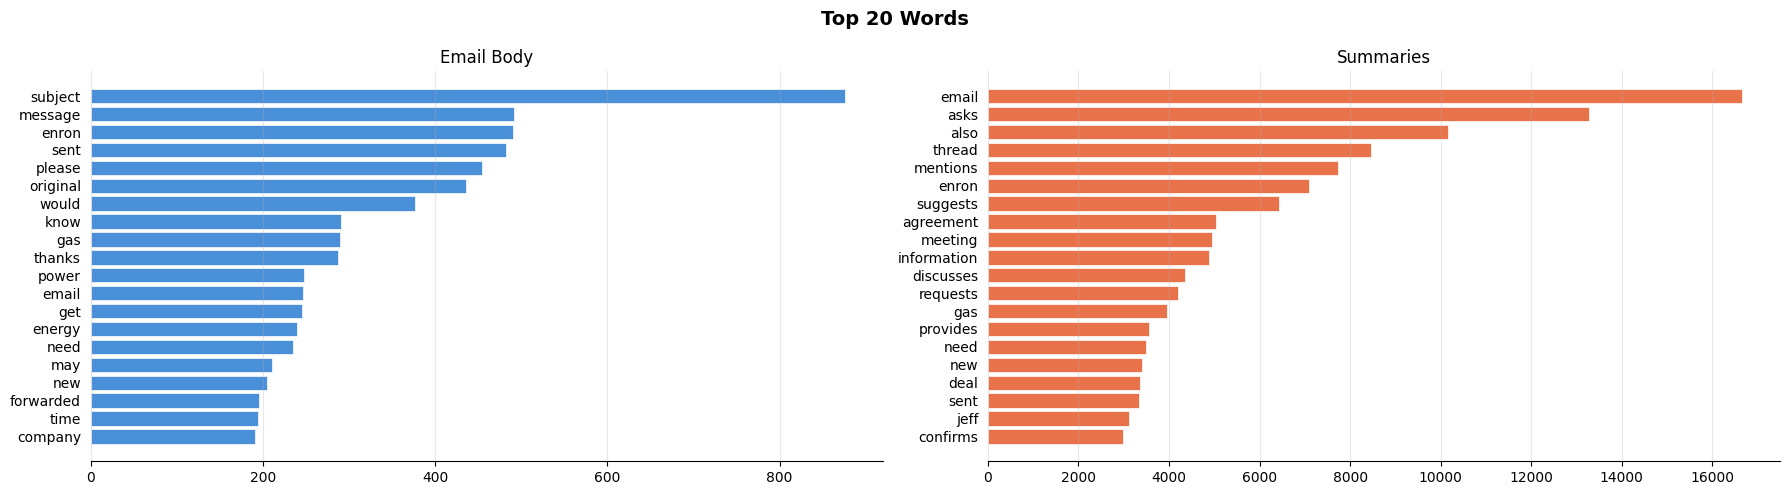

✅ Saved: eda_top_words.png


In [ ]:
# ============================================================
# FIGURE 4 — Top 20 Most Frequent Words (bar chart)
# ============================================================
def top_words(corpus, n=20):
    words = [w for w in corpus.split() if len(w) > 2]
    return Counter(words).most_common(n)

email_top   = top_words(email_corpus)
summary_top = top_words(summary_corpus)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Top 20 Words', fontsize=14, fontweight='bold')

for ax, data, color, title in zip(
    axes,
    [email_top, summary_top],
    ['#4A90D9', '#E8734A'],
    ['Email Body', 'Summaries']
):
    words, counts = zip(*data)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.spines[['top','right','left']].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_top_words.png")

📊 Dataset Statistics:
       email_len  summary_len  compression
count   20881.00     20881.00     20881.00
mean      256.44        84.35         0.41
std       523.05        20.85         0.34
min         1.00        13.00         0.00
25%        62.00        72.00         0.00
50%       155.00        84.00         0.47
75%       315.00        95.00         0.73
max     28168.00       182.00         1.00


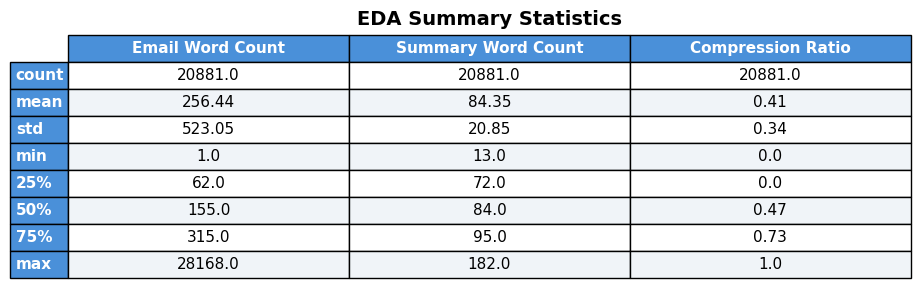

✅ Saved: eda_stats_table.png


In [ ]:
# ============================================================
# FIGURE 5 — EDA Summary Stats Table
# ============================================================
stats = df[['email_len','summary_len','compression']].describe().round(2)
print("📊 Dataset Statistics:")
print(stats.to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(cellText=stats.values.round(2),
                 rowLabels=stats.index,
                 colLabels=['Email Word Count', 'Summary Word Count', 'Compression Ratio'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 1.8)

# Style header
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#4A90D9')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F0F4F8')

plt.title('EDA Summary Statistics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('./outputs/eda_stats_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_stats_table.png")

 Extractive Summarization (TF-IDF / TextRank)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def extractive_summarize(text, num_sentences=3):
    """TextRank-style extractive summarization using TF-IDF cosine similarity."""
    sentences = nltk.sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    # Build TF-IDF matrix
    tfidf = TfidfVectorizer(stop_words='english', max_features=500)
    try:
        tfidf_matrix = tfidf.fit_transform(sentences)
    except ValueError:
        return ' '.join(sentences[:num_sentences])

    # Sentence similarity graph
    sim_matrix = cosine_similarity(tfidf_matrix)
    np.fill_diagonal(sim_matrix, 0)

    # PageRank-style scoring
    scores = sim_matrix.sum(axis=1)
    ranked_idx = np.argsort(scores)[::-1][:num_sentences]
    ranked_idx = sorted(ranked_idx)  # keep original order

    return ' '.join([sentences[i] for i in ranked_idx])

# Test it
sample_email = df['email'].iloc[0]
print("📧 Original Email (first 400 chars):")
print(sample_email[:400], '...\n')
print("📝 Extractive Summary:")
print(extractive_summarize(sample_email))

📧 Original Email (first 400 chars):
-----Original Message-----
From: =09Theriot, Kim S. =20
Sent:=09Tuesday, January 29, 2002 1:23 PM
To:=09Richardson, Stacey; Anderson, Diane; Gossett, Jeffrey C.; White, Stac=
ey W.; Murphy, Melissa; Hall, D. Todd; Sweeney, Kevin
Cc:=09Aucoin, Evelyn; Baxter, Bryce; Wynne, Rita
Subject:=09FW: Master Termination Log



 -----Original Message-----
From: =09Panus, Stephanie =20
Sent:=09Tuesday, Januar ...

📝 Extractive Summary:
=20

The following were previously on the Master Termination Log and have now be=
en marked as "Y" for a valid termination:

Atlantic Coast Fibers, Inc.=09=09=09ENA=09=09pulp/paper transactions
CNC-Containers Corporation=09=09=09EPMI=09=09master power agreement
Public Utility District No. 757497.=
01
Connect Energy Services, Inc.=09=09=09ENA=09=09liquids agreement
NGL Supply, Inc. (including Premier=09=09ENA/EGLI=09physical & financial tr=
ansactions referenced
Energy Partners, a division of NGL Supply, Inc.)
Plains Marketing, L.P

Abstractive Summarization (BART)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Using {'GPU 🚀' if device == 0 else 'CPU 🐢'}")

# Load BART directly — no pipeline task string needed
from transformers import BartForConditionalGeneration, BartTokenizer

model_name = "facebook/bart-large-cnn"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Model loaded!")

Using GPU 🚀


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

✅ Model loaded!


In [ ]:
def abstractive_summarize(text, max_len=130, min_len=30):
    """Abstractive summarization using BART — compatible with all transformers versions."""
    words = text.split()
    if len(words) > 900:
        text = ' '.join(words[:900])

    device_str = "cuda" if torch.cuda.is_available() else "cpu"

    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(device_str)

    summary_ids = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_len,
        min_length=min_len,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Test it
print(abstractive_summarize(sample_email))

The Daily Termination List for January 25 as well as the Master Termination Log, which incorporates all terminations received through January 25. The following were previously marked as "Y" for a valid termination:Atlantic Coast Fibers, Inc. (including Premier Premier Energy Partners, a division of NGL Supply, Inc.)


In [ ]:
!pip install rouge-score

 ROUGE Evaluation on Sample

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Evaluate on first N samples
N = min(50, len(df))
eval_df = df.sample(N, random_state=42).reset_index(drop=True)

results = []
for i, row in eval_df.iterrows():
    ext_sum = extractive_summarize(row['email'])
    try:
        abs_sum = abstractive_summarize(row['email'])
    except Exception:
        abs_sum = ext_sum

    ref = row['summary']
    ext_scores = scorer.score(ref, ext_sum)
    abs_scores = scorer.score(ref, abs_sum)

    results.append({
        'email': row['email'],
        'reference': ref,
        'extractive': ext_sum,
        'abstractive': abs_sum,
        'ext_rouge1': ext_scores['rouge1'].fmeasure,
        'ext_rouge2': ext_scores['rouge2'].fmeasure,
        'ext_rougeL': ext_scores['rougeL'].fmeasure,
        'abs_rouge1': abs_scores['rouge1'].fmeasure,
        'abs_rouge2': abs_scores['rouge2'].fmeasure,
        'abs_rougeL': abs_scores['rougeL'].fmeasure,
    })
    if (i+1) % 10 == 0:
        print(f"  Evaluated {i+1}/{N}...")

results_df = pd.DataFrame(results)

print("\n📊 Average ROUGE Scores:")
rouge_summary = pd.DataFrame({
    'Method': ['Extractive (TF-IDF)', 'Abstractive (BART)'],
    'ROUGE-1': [results_df['ext_rouge1'].mean(), results_df['abs_rouge1'].mean()],
    'ROUGE-2': [results_df['ext_rouge2'].mean(), results_df['abs_rouge2'].mean()],
    'ROUGE-L': [results_df['ext_rougeL'].mean(), results_df['abs_rougeL'].mean()],
}).round(4)
print(rouge_summary.to_string(index=False))
results_df.to_csv('./outputs/evaluation_results.csv', index=False)
print("\n✅ Saved: evaluation_results.csv")

  Evaluated 10/50...
  Evaluated 20/50...
  Evaluated 30/50...
  Evaluated 40/50...
  Evaluated 50/50...

📊 Average ROUGE Scores:
             Method  ROUGE-1  ROUGE-2  ROUGE-L
Extractive (TF-IDF)   0.2717   0.1038   0.1693
 Abstractive (BART)   0.2483   0.1017   0.1817

✅ Saved: evaluation_results.csv


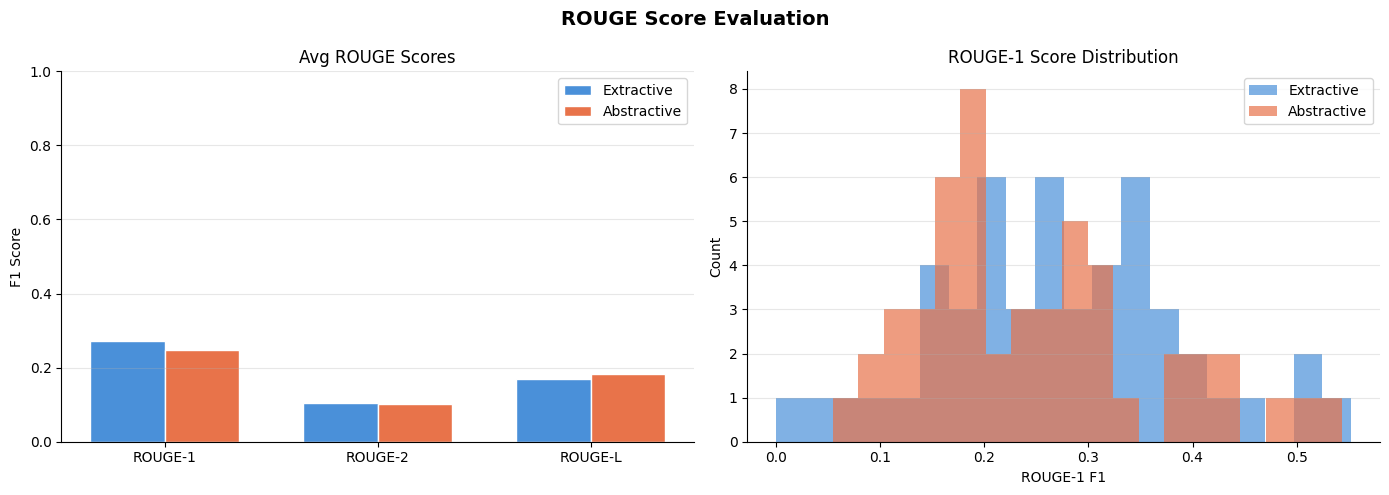

✅ Saved: rouge_evaluation.png


In [ ]:
# ============================================================
# FIGURE 6 — ROUGE Score Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROUGE Score Evaluation', fontsize=14, fontweight='bold')

# Grouped bar chart
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
ext_vals = [results_df['ext_rouge1'].mean(), results_df['ext_rouge2'].mean(), results_df['ext_rougeL'].mean()]
abs_vals = [results_df['abs_rouge1'].mean(), results_df['abs_rouge2'].mean(), results_df['abs_rougeL'].mean()]

x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, ext_vals, w, label='Extractive', color='#4A90D9', edgecolor='white')
axes[0].bar(x + w/2, abs_vals, w, label='Abstractive', color='#E8734A', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('F1 Score'); axes[0].set_title('Avg ROUGE Scores')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Distribution of ROUGE-1
axes[1].hist(results_df['ext_rouge1'], bins=20, alpha=0.7, label='Extractive', color='#4A90D9')
axes[1].hist(results_df['abs_rouge1'], bins=20, alpha=0.7, label='Abstractive', color='#E8734A')
axes[1].set_title('ROUGE-1 Score Distribution')
axes[1].set_xlabel('ROUGE-1 F1'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/rouge_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rouge_evaluation.png")

Gradio UI

In [ ]:
import gradio as gr

# Sample emails for quick testing
SAMPLE_EMAILS = [
    df['email'].iloc[0],
    df['email'].iloc[1] if len(df) > 1 else df['email'].iloc[0],
    """Hi Team,\n\nI wanted to follow up on our discussion from yesterday's meeting regarding the Q4 budget allocation. As discussed, we need to finalize the breakdown between marketing, engineering, and operations before the end of the week.\n\nMarketing has requested an additional $50k for the holiday campaign, which I think is reasonable given last year's ROI. Engineering wants to push forward with the infrastructure upgrade they've been planning since January, estimated at $120k. Operations has kept their request minimal at $30k for maintenance and supplies.\n\nTotal ask is $200k above our original allocation. Please review and respond with your approval or concerns by Thursday EOD so we can submit to finance on Friday.\n\nBest,\nSarah"""
]

summarization_log = []

def summarize_email(email_text, method, num_sentences, max_length, min_length):
    if not email_text.strip():
        return "⚠️ Please enter an email to summarize.", "", ""

    word_count   = len(email_text.split())
    char_count   = len(email_text)
    sent_count   = len(nltk.sent_tokenize(email_text))

    summary = ""
    method_used = ""

    if method in ['Extractive (TF-IDF)', 'Both']:
        ext_sum = extractive_summarize(email_text, num_sentences=int(num_sentences))
        summary += f"🔍 **Extractive Summary:**\n{ext_sum}\n\n"
        method_used = 'extractive'

    if method in ['Abstractive (BART)', 'Both']:
        try:
            abs_sum = abstractive_summarize(email_text, max_len=int(max_length), min_len=int(min_length))
            summary += f"🧠 **Abstractive Summary (BART):**\n{abs_sum}"
            method_used = 'abstractive'
        except Exception as e:
            summary += f"⚠️ Abstractive failed: {e}"

    stats = (
        f"📊 **Email Stats**\n"
        f"- Words: {word_count}\n"
        f"- Characters: {char_count}\n"
        f"- Sentences: {sent_count}\n"
    )

    if summary.strip():
        sum_words = len(summary.split())
        ratio = round(1 - sum_words / max(word_count, 1), 2)
        stats += f"- Compression: {ratio * 100:.0f}%"

    # Log result
    summarization_log.append({
        'email_preview': email_text[:100],
        'method': method,
        'summary': summary,
        'word_count': word_count,
    })

    return summary, stats, email_text[:100] + '...' if len(email_text) > 100 else email_text


def load_sample(idx):
    idx = int(idx) - 1
    return SAMPLE_EMAILS[idx % len(SAMPLE_EMAILS)]


def save_result(email_text, summary):
    if not summary:
        return "No summary to save."
    path = './outputs/manual_summary.txt'
    with open(path, 'w') as f:
        f.write("=== EMAIL ===\n")
        f.write(email_text + '\n\n')
        f.write("=== SUMMARY ===\n")
        f.write(summary)
    return f"✅ Saved to {path}"


with gr.Blocks(title="📧 Email Summarizer", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📧 NLP Email Summarizer
    Paste an email below, choose a summarization method, and get an instant summary.
    """)

    with gr.Row():
        with gr.Column(scale=2):
            email_input = gr.Textbox(
                label="📨 Email Text",
                placeholder="Paste your email here...",
                lines=12,
                max_lines=30
            )
            with gr.Row():
                sample_btn1 = gr.Button("📄 Load Sample 1", size='sm')
                sample_btn2 = gr.Button("📄 Load Sample 2", size='sm')
                sample_btn3 = gr.Button("📄 Load Sample 3", size='sm')

        with gr.Column(scale=1):
            method = gr.Radio(
                choices=['Extractive (TF-IDF)', 'Abstractive (BART)', 'Both'],
                value='Both',
                label="🔧 Method"
            )
            num_sentences = gr.Slider(1, 10, value=3, step=1, label="Extractive: Number of Sentences")
            max_length    = gr.Slider(50, 300, value=130, step=10, label="Abstractive: Max Length (words)")
            min_length    = gr.Slider(10, 100, value=30, step=5,  label="Abstractive: Min Length (words)")
            summarize_btn = gr.Button("⚡ Summarize", variant="primary")

    with gr.Row():
        with gr.Column(scale=2):
            summary_out = gr.Markdown(label="📝 Summary")
        with gr.Column(scale=1):
            stats_out   = gr.Markdown(label="📊 Stats")
            preview_out = gr.Textbox(label="🔍 Email Preview", interactive=False, lines=2)
            save_btn    = gr.Button("💾 Save Result")
            save_status = gr.Textbox(label="", interactive=False)

    # Wire events
    summarize_btn.click(
        fn=summarize_email,
        inputs=[email_input, method, num_sentences, max_length, min_length],
        outputs=[summary_out, stats_out, preview_out]
    )

    sample_btn1.click(fn=lambda: load_sample(1), outputs=email_input)
    sample_btn2.click(fn=lambda: load_sample(2), outputs=email_input)
    sample_btn3.click(fn=lambda: load_sample(3), outputs=email_input)

    save_btn.click(fn=save_result, inputs=[email_input, summary_out], outputs=save_status)

demo.launch(share=True, debug=False)

/tmp/ipykernel_1116/3094538666.py:76: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="📧 Email Summarizer", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40702d1f8778b2d637.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
